# Multiple Polynomial Regression

### Creating and visualizing dataset

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px

In [2]:
x = 7 * np.random.rand(200, 1) - 2.8
y = 7 * np.random.rand(200, 1) - 2.8

In [3]:
x[:5], y[:5]

(array([[-1.62782628],
        [ 2.40936588],
        [ 1.21058242],
        [ 3.04590474],
        [ 0.29949973]]),
 array([[ 0.57542428],
        [-1.95827892],
        [-1.85501546],
        [ 3.53274667],
        [-0.78767491]]))

In [4]:
z = x**2 + y**2 + 0.2*x + 0.2*y + 0.1*x*y + 2 + np.random.randn(200,1)
# z = x^2 + y^2 + 0.2x + 0.2y + 0.1xy + 2

In [5]:
z[:5]

array([[ 4.15235372],
       [11.42582979],
       [ 6.39331354],
       [25.58735619],
       [ 1.9737579 ]])

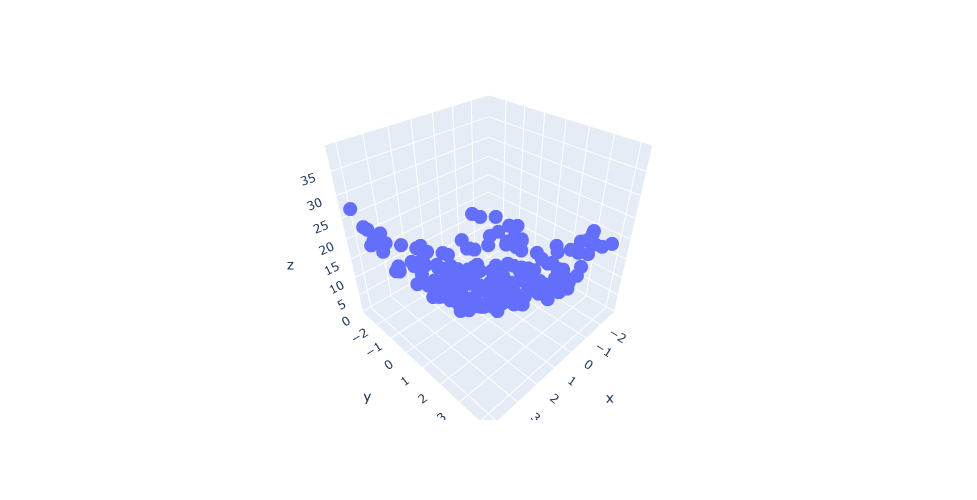

In [6]:
fig = px.scatter_3d(x=x.ravel(), y=y.ravel(), z=z.ravel())
fig.update_layout(height=500, width=800)
fig.show()

### Training **simply Polynomial Regression**

In [7]:
from sklearn.linear_model import LinearRegression

In [8]:
lin_reg = LinearRegression()

In [9]:
lin_reg.fit(np.array([x, y]).reshape(200,2), z)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [84]:
lin_reg.coef_, lin_reg.intercept_

(array([[0.46841503, 0.06040404]]), array([11.12084174]))

### Visualizing the model's surface

In [10]:
x_input = np.linspace(x.min(), x.max(), 20)
y_input = np.linspace(y.min(), y.max(), 20)

In [11]:
x_input

array([-2.76539318, -2.40065583, -2.03591848, -1.67118113, -1.30644377,
       -0.94170642, -0.57696907, -0.21223172,  0.15250563,  0.51724298,
        0.88198034,  1.24671769,  1.61145504,  1.97619239,  2.34092974,
        2.7056671 ,  3.07040445,  3.4351418 ,  3.79987915,  4.1646165 ])

In [12]:
xGrid, yGrid = np.meshgrid(x_input, y_input)

In [13]:
final = np.vstack((xGrid.ravel().reshape(1,400), yGrid.ravel().reshape(1,400))).T

In [28]:
z_final = lin_reg.predict(final).reshape(20, 20)

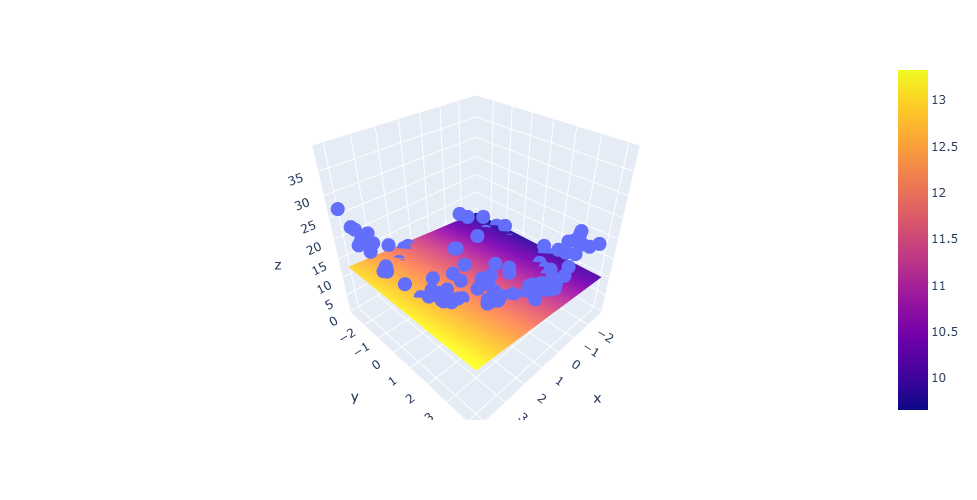

In [15]:
import plotly.graph_objects as go
fig = px.scatter_3d(x=x.ravel(), y=y.ravel(), z=z.ravel())
fig.update_layout(height=500, width=800)
fig.add_trace(go.Surface(x=x_input, y=y_input, z=z_final))
fig.show()

### Applying Polynomial Regression

In [16]:
from sklearn.preprocessing import PolynomialFeatures

In [17]:
x_multi = np.array([x, y]).reshape(200, 2)

In [98]:
poly = PolynomialFeatures(degree=2+1)

In [99]:
x_multi_trans = poly.fit_transform(x_multi)

In [100]:
print('Input features:', poly.n_features_in_)
print('Output features:', poly.n_output_features_)
print('Powers:\n', poly.powers_)

Input features: 2
Output features: 10
Powers:
 [[0 0]
 [1 0]
 [0 1]
 [2 0]
 [1 1]
 [0 2]
 [3 0]
 [2 1]
 [1 2]
 [0 3]]


In [101]:
x_multi_trans.shape

(200, 10)

### Training model

In [102]:
poly_reg = LinearRegression()

In [103]:
poly_reg.fit(x_multi_trans, z)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [104]:
poly_reg.coef_, poly_reg.intercept_

(array([[ 0.        ,  0.17460334,  0.39774617, -0.38178487, -0.17804459,
          0.72700092,  0.12366538,  0.0557866 , -0.03743593, -0.15786486]]),
 array([9.80101834]))

### Visualizing model's surface

In [105]:
x_test_multi = poly.transform(final)

In [106]:
x_test_multi.shape

(400, 10)

In [107]:
z_final_poly = poly_reg.predict(x_test_multi).reshape(20, 20)

In [108]:
fig = px.scatter_3d(x=x.ravel(), y=y.ravel(), z=z.ravel())
fig.update_layout(height=500, width=800)
fig.add_trace(go.Surface(x=x_input, y=y_input, z=z_final_poly))
fig.update_layout(scene=dict(zaxis=dict(range=[0, 35])))
fig.show()